# Assignment 2 - [EDOS Task B](https://github.com/rewire-online/edos)

Given an input text sentence, the task is to label the sentence as not-sexist or one of these four sexist categories: (1) threats, (2)  derogation, (3) animosity, (4) prejudiced discussion.

| Student | ID | Email |
|-----------|-----------|-----------|
|  Flavio D'Amato   | 0001169011| flavio.damato@studio.unibo.it       |
|  Luca Andaloro    | 0001168042| luca.andaloro2@studio.unibo.it       |
|  Alessio La Torre | 0001195123| alessio.latorre@studio.unibo.it       |
|  Lorenzo Venturi  | 0001138787| lorenzo.venturi14@studio.unibo.it       |

### Imports

In [ ]:
#########################
# standard libraries
#########################
import os
import re
import json
from pathlib import Path
from typing import List
#########################
# data manipulations
#########################
import numpy as np
import pandas as pd
from tqdm import tqdm

#########################
# visualization libraries
#########################
import matplotlib.pyplot as plt
import seaborn as sns

#########################
# pytorch libraries
#########################
import torch

#########################
# transformers libraries
#########################
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from sentence_transformers import SentenceTransformer, util

#########################
# metrics
#########################
from sklearn.metrics import (
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report
)

#########################
# external utilities
#########################
import gdown

#########################
# error_analysis utils
#########################
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from matplotlib.ticker import MaxNLocator
import math
from collections import Counter

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/flaviodamato/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In this cell we define a single configuration dictionary that collects all the main parameters of the project. This helps us keep everything in one place, so we can quickly check or modify device settings, embeddings, model hyperparameters, paths, and seeds without digging through the whole code.


In [15]:
cfg = {

    #=================== Model cards ==========================#                            # FINAL MODEL USED IN THIS ASSIGNMENT
    'Phi3-mini': "microsoft/Phi-3-mini-4k-instruct",
    'Mistral-v3': "mistralai/Mistral-7B-Instruct-v0.3",

    ######################################################################                  # USED TO EASILY CHANGE MODEL TO USE
    #=== All other model cards =#
    'Mistral-v2': "mistralai/Mistral-7B-Instruct-v0.2",
    'LLama-v3.1': "meta-llama/Meta-Llama-3.1-8B-Instruct",
    'TinyLlama': "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    'Deepseek-R1': "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
    'Qwen3': "Qwen/Qwen3-1.7B",
    ######################################################################

    "mapping": {                                                                            # Mapping for categories
        'not-sexist': 0,
        'threats': 1,
        'derogation': 2,
        'animosity': 3,
        'prejudiced': 4
    },

    #=================== Few shot prompt ======================#
    "num_per_classes": [2, 3, 4],                                                           # Num of examples per classes in few shot prompting

    #=========== generation config hyperparameters ============#
    "max_new_tokens": 30,                                                                   # Max num of tokens the model can generate in output
    "num_return_sequences": 1,                                                              # Num of return sequences in model output

    #=================== Paths ================================#
    'data_path': "./data",                                                                  # Path where to save both test and demonstration dataset

    'metrics_path': "./metrics",                                                            # Path to upload data from pretrained models, used to avoid rerunning for error analysis
    'metrics_filename': "models_metrics.json",

    #=================== urls =================================#
    'data_url': "https://drive.google.com/drive/folders/1jUeE-XEWzAcypKn7vGnR5tQH8_7D1m-W?usp=sharing",       # Url to download data
    'metrics_url': "https://drive.google.com/drive/folders/1QuzfwQXyMTybvIzQkrGY29dZfGTKst4G?usp=sharing"     # Url to download metrics
}

In [ ]:
!hf auth login

In [1]:
!pip install transformers
!pip install datasets
!pip install accelerate -U
!pip install evaluate
!pip install -U bitsandbytes
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.1.2
    Uninstalling sentence-transformers-5.1.2:
      Successfully uninstalled sentence-transformers-5.1.2


We loaded the dataset on a public google drive folder. In the function below, we use gdown library to download all the files and folders from the public google drive URL.

In [4]:
def download_all_files_gdown(path: Path, URL: str) -> None:
    """
    Download all the files and folders from the public Google Drive URL.

    :param path: the path where to save the files.
    :param URL: the URL string of the Google Drive folder.
    """
    os.makedirs(path, exist_ok=True)

    gdown.download_folder(
        url=URL,
        output=str(path),
        quiet=False,
        remaining_ok=True
    )

In [5]:
download_all_files_gdown(cfg["data_path"], cfg["data_url"])

Retrieving folder contents


Processing file 1flsdXahYkAEUkIm2Jlp_fC5ujrKNuv4C a2_test.csv
Processing file 14yTjCnvhsDlnA9kRW6gKEQC4xADhWIHe demonstrations.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1flsdXahYkAEUkIm2Jlp_fC5ujrKNuv4C
To: /Users/flaviodamato/Documents/UniBo/lezioni/2_1/NLP/NLP_project/assignment2/Explainable_Detection_of_Online_Sexism-EDOS--TaskB/data/a2_test.csv
100%|██████████| 51.8k/51.8k [00:00<00:00, 24.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=14yTjCnvhsDlnA9kRW6gKEQC4xADhWIHe
To: /Users/flaviodamato/Documents/UniBo/lezioni/2_1/NLP/NLP_project/assignment2/Explainable_Detection_of_Online_Sexism-EDOS--TaskB/data/demonstrations.csv
100%|██████████| 224k/224k [00:00<00:00, 3.79MB/s]
Download completed


Encode data into a `pandas.DataFrame`

In [21]:
test_data_path = os.path.join(cfg["data_path"], "a2_test.csv")
df = pd.read_csv(test_data_path, sep=',')
df.head()

,rewire_id,text,label_category
0,sexism2022_english-11647,She may be worth what someone paid for her in ...,derogation
1,sexism2022_english-15883,The men who white knight for women eventually ...,prejudiced
2,sexism2022_english-12494,Two thoughts to keep in mind about women and A...,derogation
3,sexism2022_english-26,"Wimmin. No matter how good they have it, they'...",prejudiced
4,sexism2022_english-7475,"So just a few months ago, while Republican wom...",prejudiced


# [Task 1 - 0.5 points] Model setup

In the following cell we create the `models` dictionary, which serves as a container for all information related to each model we intend to use. The dictionary keys are the model names, and for each model we initially store its model card. Additional elements, such as predictions, evaluation metrics and other model-specific data will be added later to the dictionary. Structuring the information in this way allows for clean organization and makes it easy to switch between models by modifying only the `model_name` variables defined below.

In [9]:
# MODEL NAME AVAILABLE: {Mistral-v2, Mistral-v3, LLama-v3.1, Phi3-mini, TinyLlama, DeepSeek-R1, Qwen3}
MODEL_NAME1 = "Phi3-mini"
MODEL_NAME2 = "Mistral-v3"

models = {
    MODEL_NAME1: {
        "model_card": cfg[MODEL_NAME1],
    },

    MODEL_NAME2: {
        "model_card": cfg[MODEL_NAME2],
    }
}

The following function loads the model and its corresponding tokenizer from HuggingFace, applies the specified quantization settings, and configures the generation parameters to prepare the model for inference.

In [7]:
def prepare_model(model_card: str, quant_config, max_new_tokens: int = 30, num_return_sequences: int = 1):
    """
    Prepare the model and the tokenizer for inference phase
    :param model_card: the model card from Hugging face

    :return: the model and the tokenizer
    """

    # Load model
    model = AutoModelForCausalLM.from_pretrained(
        model_card,
        return_dict=True,
        quantization_config=quant_config,
        device_map='auto'
    )

    # Load Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_card)
    tokenizer.pad_token = tokenizer.eos_token

    # Preparing generation config
    generation_config = model.generation_config
    generation_config.max_new_tokens = max_new_tokens
    generation_config.eos_token_id = tokenizer.eos_token_id
    generation_config.pad_token_id = tokenizer.eos_token_id
    generation_config.temperature = None
    generation_config.num_return_sequences = num_return_sequences

    return model, tokenizer

In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

Prepare all models for inference and store model-specific informations into the `models` dictionary

In [9]:
for model_name, model_info in models.items():
    model,tokenizer=prepare_model(model_card=model_info['model_card'],
                                  quant_config=bnb_config,
                                  max_new_tokens=cfg["max_new_tokens"],
                                  num_return_sequences=cfg["num_return_sequences"])
    model_info['tokenizer'] = tokenizer
    model_info['model'] = model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

# [Task 2 - 1.0 points] Prompt setup

In [ ]:
prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

This function converts each input text into an instruction prompt using the provided template, then tokenizes it with the tokenizer to prepare it for inference.

In [10]:
def prepare_prompts(texts: list, prompt_template: str, tokenizer):
  """
    This function format input text samples into instructions prompts.

    :param texts: input texts to classify via prompting
    :param prompt_template: the prompt template provided in this assignment
    :param tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card
    :return
      input texts to classify in the form of instruction prompts
  """
  instructions_prompts = []
  for text in texts:
    prompt = tokenizer.apply_chat_template(prompt_template,
                                       tokenize=False,
                                       add_generation_prompt=True)
    prompt_tokenized = tokenizer(prompt.format(text=text),
                                       return_tensors='pt',
                                       padding=True,
                                       truncation=True,
                                       max_length=2000).to('cuda')
    instructions_prompts.append(prompt_tokenized)

  return instructions_prompts

Generate and store zero-shot prompts for each model.

In [ ]:
for model_name, model_info in models.items():
    model_info["prompts_zero_shot"] = prepare_prompts(texts=df['text'],
                                                      prompt_template=prompt,
                                                      tokenizer=model_info['tokenizer'])

# [Task 3 - 1.0 points] Inference

We are now ready to define the inference loop where we prompt the model with each pre-processed sample.

In [11]:
def generate_responses(model, prompts: list):
  """
    This function implements the inference loop for a LLM model.
    Given a set of examples, the model is tasked to generate
    a response.

    :param model: LLM model instance for prompting
    :param prompts: pre-processed text samples

    :return:
      generated responses
  """
  responses=[]
  with torch.inference_mode():
    for prompt in tqdm(prompts, desc="Generation of responses"):
      response_generated=model.generate(
          input_ids=prompt['input_ids'].to(model.device),
          attention_mask=prompt['attention_mask'].to(model.device),
          generation_config=model.generation_config,
          do_sample=False,
          use_cache=True,
      )
      responses.append(response_generated)
  return responses

In [12]:
def process_response(response):
  """
    This function takes a textual response generated by the LLM
    and processes it to map the response to a binary label.

    :param response: generated response from LLM

    :return:
      parsed classification response.
      Use the following mapping:
      {
        'not-sexist': 0,
        'threats': 1,
        'derogation': 2,
        'animosity': 3,
        'prejudiced': 4
      }
  """
  check = [m for m in re.finditer('ANSWER:',response)][-1]
  found = response[check.end():].strip().lower()
  label = re.split(r'[\s\(]', found)[0]

  if 'prejudiced' in label:
        label = 'prejudiced'

  return cfg["mapping"].get(label, 5)

In [13]:
def decode_responses(responses: list, model_name: str):
  """
  Convert the token sequences generated by the model into readable text using the model's tokenizer.


  :param responses: list of token ID sequences produced by the model
  :param model_name: name of the model to select the appropriate tokenizer

  :return: list of decoded text strings
  """
  decoded_responses = []
  for resp in responses:
      decoded_response = models[model_name]['tokenizer'].decode(resp[0],skip_special_tokens=True)
      decoded_responses.append(decoded_response)
  return decoded_responses

Generate zero-shot responses for each model, decode them into text, and store both tokenized and decoded outputs in the `models` dictionary.

In [ ]:
for model_name, model_info in models.items():
    responses = generate_responses( model=model_info['model'],
                                    prompts=model_info["prompts_zero_shot"])

    decoded_responses = decode_responses(responses=responses,
                                model_name=model_name)

    model_info['responses_zero_shot'] = responses
    model_info['decoded_responses_zero_shot'] = decoded_responses

Generation of responses: 100%|██████████| 300/300 [10:50<00:00,  2.17s/it]


# [Task 4 - 0.5 points] Metrics

The following function converts model predicted classes into numeric labels and computes the macro F1 score and fail ratio. Predictions mapped to class 5 (responses that could not be interpreted) are treated as class 0 for the F1 computation.

In [14]:
def compute_metrics(y_pred, y_true):
  """
    This function takes predicted and ground-truth labels and compute
    metrics. In particular, this function compute F1-score and
    fail-ratio metrics. This function internally invokes
    `process_response` to compute metrics.

    :param y_pred: parsed LLM responses
    :param y_true: ground-truth binary labels

    :return: dictionary containing desired metrics
  """

  preds = []
  trues = []
  errors_indexes=[]
  errors_answer=[]
  for i in range(len(y_pred)):
    processed_label = process_response(y_pred[i])

    if processed_label==5:
      errors_indexes.append(i)
      errors_answer.append(y_pred[i])
      preds.append(0)
    else:
      preds.append(processed_label)

    trues.append(cfg["mapping"].get(y_true[i]))

  # as told in class we compute f1 considering models errors as class 0
  _, _, f1_score, _ = precision_recall_fscore_support(trues, preds, average="macro", zero_division=0)

  return {
      'macro_f1': f1_score,
      'fail_ratio': len(errors_indexes) / len(preds),
      'pred_labels': preds,
      'true_labels': trues,
      'errors_indexes': errors_indexes,
      'errors_answer': errors_answer
      }


In [ ]:
for model_name, model_info in models.items():
    metrics_dict = compute_metrics(y_pred = model_info['decoded_responses_zero_shot'],
                                   y_true = df['label_category'])

    model_info['metrics_dict_zero_shot'] = metrics_dict

    print(f"#------ Metrics for model: {model_name} ------#")
    print(f"Macro F1: {metrics_dict['macro_f1']}")
    print(f"Fail ratio: {metrics_dict['fail_ratio']}\n")

#------ Metrics for model: Phi3-mini ------#
Macro F1: 0.3953084122010436
Fail ratio: 0.0

#------ Metrics for model: Mistral-v3 ------#
Macro F1: 0.3664021811562509
Fail ratio: 0.0033333333333333335



# [Task 5 - 1.0 points] Few-shot Inference

In [6]:
prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

Load ``demonstrations.csv`` and encode it into a ``pandas.DataFrame`` object.

In [10]:
demonstration_data_path = os.path.join(cfg["data_path"], "demonstrations.csv")
df_few_shot = pd.read_csv(demonstration_data_path, sep=',')
print(df_few_shot['label_category'].value_counts())

label_category
derogation    200
threats       200
animosity     200
prejudiced    200
not-sexist    200
Name: count, dtype: int64


In [11]:
def build_few_shot_demonstrations(demonstrations: pd.DataFrame, num_per_class: int = 2):
  """
  :param demonstrations DataFrame wrapping demonstrations examples
  :param num_per_class: number of demonstrations per class

  :return: list of demonstrations to inject into the prompt template.
  """
  demonstrations_samples_categories=[]
  for category in demonstrations['label_category'].unique():
    demonstrations_samples_categories.append(demonstrations[demonstrations['label_category']==category].sample(n=num_per_class,random_state=42))

  formatted_demonstrations = "\n".join(
        f"TEXT: {sample['text']}\nANSWER: {sample['label_category']}"
        for df in demonstrations_samples_categories
        for sample in df.to_dict(orient="records")
    )
  return formatted_demonstrations

In [12]:
few_shots_demonstrations={}
for num_examples in cfg["num_per_classes"]:
  few_shots_demonstrations[num_examples] = build_few_shot_demonstrations(demonstrations = df_few_shot,
                                                                         num_per_class = num_examples)

In [13]:
print(few_shots_demonstrations)

{2: "TEXT: Good Christian Girl > Into Bondage Are you retarded? How is the cognitive dissonance not blowing your mind apart? All women like it rough but the ones in BDSM are damaged beyond belief and completely fucked up in the head.\nANSWER: derogation\nTEXT: No one knows the struggle of young black men like some old white bitch from Arkansas. Yea girl you go. #presidentialdebates\nANSWER: derogation\nTEXT: Two things. 1st is when a woman posts that, she's saying she's ignorant. Ignorance is the lack of awareness. 2nd is a little thug in him is an invitation to slap her around, you know, just a little.\nANSWER: threats\nTEXT: I'd just pretend to get locked down, set a wedding date, get her pregnant, then leave the country. Nobody is going to extradite me based on that horseshit allegation.\nANSWER: threats\nTEXT: [USER] oi cunt do a stream\nANSWER: animosity\nTEXT: I heard it as the 6 of 6: * 6 months out of a relationship * 6 ft or taller * 6 figure income * 6 pack * 6” or greater * 

The following function converts each input text into an instruction prompt using the provided template and adding the previously generated demonstrations, then tokenizes it with the tokenizer to prepare it for inference.

In [17]:
def prepare_prompts_few_shot(texts: list,
                            prompt_template: list,
                            tokenizer,
                            demonstrations: str):
  """
  :param texts: list of raw input texts to classify / process
  :param prompt_template: chat-style prompt template (list of messages)
  :param tokenizer: HuggingFace tokenizer associated with the model
  :param demonstrations: formatted few-shot demonstration block (string)

  :return: list of tokenized prompts ready for model inference
  """

  instructions_prompts = []

  for text in texts:
    prompt = tokenizer.apply_chat_template(prompt_template,
                                       tokenize=False,
                                       add_generation_prompt=True)

    prompt_tokenized = tokenizer(prompt.format(text=text,examples=demonstrations),
                                       return_tensors='pt',
                                       padding=True,
                                       truncation=True,
                                       max_length=2000).to('cuda')

    instructions_prompts.append(prompt_tokenized)

  return instructions_prompts

In [ ]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    model_info[f"prompts_few_shots_{num_examples}"] = prepare_prompts_few_shot(texts = df["text"],
                                                                               prompt_template = prompt,
                                                                               tokenizer = model_info["tokenizer"],
                                                                               demonstrations = few_shots_demonstrations[num_examples])

Generate few-shot responses for each model and number of examples, decode them into text, and store both tokenized and decoded outputs in the `models` dictionary.

In [ ]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    responses =  generate_responses(model = model_info['model'],
                                    prompts = model_info[f"prompts_few_shots_{num_examples}"])

    decoded_responses = decode_responses(responses=responses,
                                         model_name = model_name)

    model_info[f'responses_few_shots_{num_examples}'] = responses
    model_info[f'decoded_responses_few_shots_{num_examples}'] = decoded_responses

Generation of responses: 100%|██████████| 300/300 [43:11<00:00,  8.64s/it]


Compute metrics for each model and few-shot setup, store the results in the `models` dictionary

In [ ]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    metrics_dict = compute_metrics(y_pred = model_info[f'decoded_responses_few_shots_{num_examples}'],
                                                                          y_true = df['label_category'])
    model_info[f'metrics_dict_few_shots_{num_examples}'] = metrics_dict

    print(f"#---------- Metrics few_shots_{num_examples} model: {model_name} -----------#")
    print(f"Macro F1: {metrics_dict['macro_f1']}")
    print(f"Fail ratio: {metrics_dict['fail_ratio']}\n")

#---------- Metrics few_shots_2 model: Phi3-mini -----------#
Macro F1: 0.4169621179781666
Fail ratio: 0.0

#---------- Metrics few_shots_3 model: Phi3-mini -----------#
Macro F1: 0.4581733143727689
Fail ratio: 0.0

#---------- Metrics few_shots_4 model: Phi3-mini -----------#
Macro F1: 0.429704556994161
Fail ratio: 0.0

#---------- Metrics few_shots_2 model: Mistral-v3 -----------#
Macro F1: 0.3942171606946815
Fail ratio: 0.006666666666666667

#---------- Metrics few_shots_3 model: Mistral-v3 -----------#
Macro F1: 0.46896826941098785
Fail ratio: 0.013333333333333334

#---------- Metrics few_shots_4 model: Mistral-v3 -----------#
Macro F1: 0.49256055099084656
Fail ratio: 0.01



In [ ]:
print(models[MODEL_NAME2]['decoded_responses_few_shots_4'][20])

You are an annotator for sexism detection.

Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: TEXT: Good Christian Girl > Into Bondage Are you retarded? How is the cognitive dissonance not blowing your mind apart? All women like it rough but the ones in BDSM are damaged beyond belief and com

In [ ]:
#TEMPORARY
dict_to_save = {MODEL_NAME1: {},
                MODEL_NAME2: {}
                }

for model_name, model_info in models.items():
    dict_to_save[model_name]["model_card"] = model_info["model_card"]

    # Zero-shot metrics
    zero_shot_key = 'metrics_dict_zero_shot'
    if zero_shot_key in model_info:
        metrics = model_info[zero_shot_key]

        metrics_to_save = {
            'macro_f1': metrics['macro_f1'],
            'fail_ratio': metrics['fail_ratio'],
            'pred_labels': metrics['pred_labels'],
            'errors_indexes': metrics['errors_indexes'],
            'errors_answer': metrics['errors_answer']
        }


        dict_to_save[model_name][zero_shot_key] = metrics_to_save

    # Few-shot metrics
    for num_examples in cfg["num_per_classes"] :
        few_shot_key = f'metrics_dict_few_shots_{num_examples}'
        decoded_key = f'decoded_responses_few_shots_{num_examples}'

        if few_shot_key in model_info:
            metrics = model_info[few_shot_key]


            metrics_to_save = {
                'macro_f1': metrics['macro_f1'],
                'fail_ratio': metrics['fail_ratio'],
                'pred_labels': metrics['pred_labels'],
                'errors_indexes': metrics['errors_indexes'],
                'errors_answer': metrics['errors_answer']
            }
            dict_to_save[model_name][few_shot_key] = metrics_to_save

# Save the extracted metrics to a JSON file
output_filename = os.path.join(cfg["metrics_path"],cfg["metrics_filename"])

with open(output_filename, 'w') as f:
    json.dump(dict_to_save, f, indent=4)

print(f"Model metrics saved to {output_filename}")

Model metrics saved to ./metrics


In [ ]:
from google.colab import files
files.download(output_filename)

# [Task 6 - 1.0 points] Error Analysis

Uncomment the following lines to download the models metrics already computed of the models from Google Drive

In [34]:
download_all_files_gdown(cfg["metrics_path"], cfg["metrics_url"])
output_filename = os.path.join(cfg["metrics_path"],cfg["metrics_filename"])
with open(output_filename, 'r') as f:
 models=json.load(f)

Retrieving folder contents


Processing file 1w4IvwGhtCW4wJIn98ylhKwHDJeP4VVQy models_metrics.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1w4IvwGhtCW4wJIn98ylhKwHDJeP4VVQy
To: /Users/flaviodamato/Documents/UniBo/lezioni/2_1/NLP/NLP_project/assignment2/Explainable_Detection_of_Online_Sexism-EDOS--TaskB/metrics/models_metrics.json
100%|██████████| 111k/111k [00:00<00:00, 2.82MB/s]
Download completed


In [17]:
def classification_performance_comparison(models_dict: dict):
  """
  This function compares the classification performance of
  the models using several prompt techniques.
  Given the models results prints a table of results and
  a graph comparison.

  :param models_dict: dictionary containing the models results
                      for each prompting techniques
  """

  output_df=pd.DataFrame(columns=['model_name','prompt_technique','macro_f1','fail_ratio'])

  for model_name, model_info in models_dict.items():
    zero_shot_key = "metrics_dict_zero_shot"
    output_df.loc[len(output_df)]=[model_name,
                                    'zero_shot',
                                    model_info[zero_shot_key]['macro_f1'],
                                    model_info[zero_shot_key]['fail_ratio']]

    for num_examples in cfg["num_per_classes"]:
      few_shot_key = f'metrics_dict_few_shots_{num_examples}'
      output_df.loc[len(output_df)]=[model_name,
                                    f'few_shots_{num_examples}',
                                    model_info[few_shot_key]['macro_f1'],
                                    model_info[few_shot_key]['fail_ratio']]
  display(output_df)

  # graph computations
  prompt_techniques=output_df["prompt_technique"].unique().tolist()
  x=range(len(prompt_techniques))
  fig,axes = plt.subplots(1,2,figsize=(12,4),sharex=True)
  for model in output_df['model_name'].unique():
    data_to_plot=output_df[output_df["model_name"]==model]
    axes[0].plot(x,data_to_plot["macro_f1"],marker="o",label=model)
    axes[1].plot(x,data_to_plot["fail_ratio"],marker="o",label=model)

  axes[0].legend()
  axes[1].legend()
  axes[0].set_title("Macro F1 Comparison")
  axes[1].set_title("Fail Ratio Comparison")
  axes[0].set_xticks(x)
  axes[1].set_xticks(x)
  axes[0].set_xticklabels(prompt_techniques,rotation=30,ha="right")
  axes[1].set_xticklabels(prompt_techniques,rotation=30,ha="right")

,model_name,prompt_technique,macro_f1,fail_ratio
0,Phi3-mini,zero_shot,0.395308,0.000000
1,Phi3-mini,few_shots_2,0.416962,0.000000
2,Phi3-mini,few_shots_3,0.458173,0.000000
3,Phi3-mini,few_shots_4,0.429705,0.000000
4,Mistral-v3,zero_shot,0.366402,0.003333
5,Mistral-v3,few_shots_2,0.394217,0.006667
6,Mistral-v3,few_shots_3,0.468968,0.013333
7,Mistral-v3,few_shots_4,0.492561,0.010000


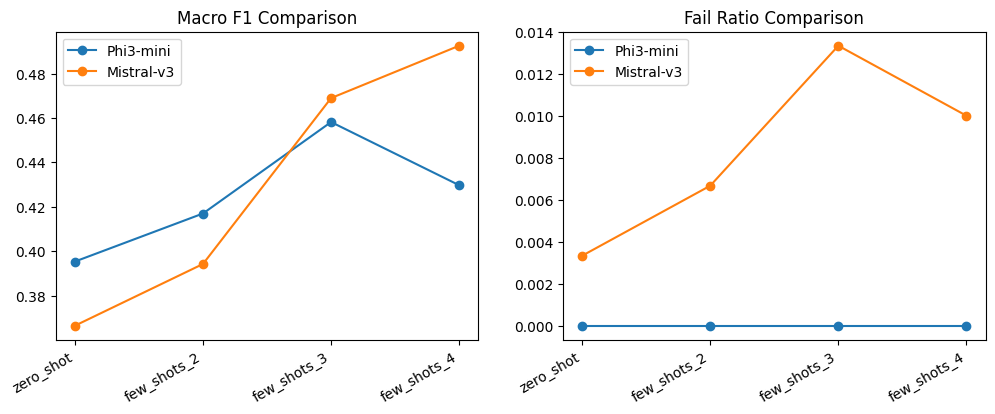

In [18]:
classification_performance_comparison(models)

As we can see from the plot above, when the number of tokens in the prompt becomes too large, the Phi-3 Mini (3.8 B parameters) model struggles to handle all the tokens, which results in its inability to properly follow the provided instructions. On the other hand, Mistral-v3(7.3 B parameters), thanks to its larger number of parameters, is able to correctly process all the input tokens and effectively benefit from the greater number of provided examples. Notably, Mistral-v3 fail ratio is not zero. We further investigate this behavior in the following cells.

In [19]:
def plot_classification_report(y_pred:np.ndarray,y_true:np.ndarray,model_name:str, mapping: dict, ax):
    """
    Function to plot classification report as heatmap.

    :param y_pred: predicted labels
    :param y_true: ground-truth labels
    :param model_name: name of the model
    :param mapping: mapping dictionary for labels
    :param ax: matplotlib axis to plot on
    """

    cr=classification_report(y_true,y_pred,output_dict=True,zero_division=0)
    cr=pd.DataFrame(cr).T

    cr.index = list(mapping.keys()) + ["accuracy", "macro avg", "weighted avg"]

    sns.heatmap(
        cr.iloc[:,:].astype(float),
        annot=True,
        fmt=".2f",
        cmap="Greens",
        cbar=False,
        xticklabels=cr.columns,
        yticklabels=cr.index,
        linewidths=0.6,
        linecolor="black",
        ax=ax
    )

    ax.set_facecolor("white")
    ax.set_title(f'CR {model_name}',fontsize=14,weight="bold")
    ax.tick_params(axis='x',labelsize=10)
    ax.tick_params(axis='y',labelsize=10)


def plot_confusion_matrix(y_pred:np.ndarray,y_true:np.ndarray,model_name:str,ax):
    """
    Function to plot the confusion matrix.

    :param y_pred: predicted labels
    :param y_true: ground-truth labels
    :param model_name: name of the model
    :param ax: matplotlib axis to plot on
    """
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens",colorbar=False,ax=ax)

    ax.set_facecolor("white")
    ax.set_title(f'CM {model_name}',fontsize=14,weight="bold")
    ax.set_xlabel("Predicted Labels",fontsize=12)
    ax.set_ylabel("True Labels",fontsize=12)
    ax.tick_params(axis='x',labelsize=10)
    ax.tick_params(axis='y',labelsize=10)

We decide to carry out the error analysis now on considering for each model a comparison between zero shot and the best few_shots configuration visible in the previous graph, for that reason we will consider:
- zero shot and few_shots with **3** as ``num_per_class`` examples for Phi3-mini.
- zero shot and few_shots with **4** as ``num_per_class`` examples for Mistral-V3.

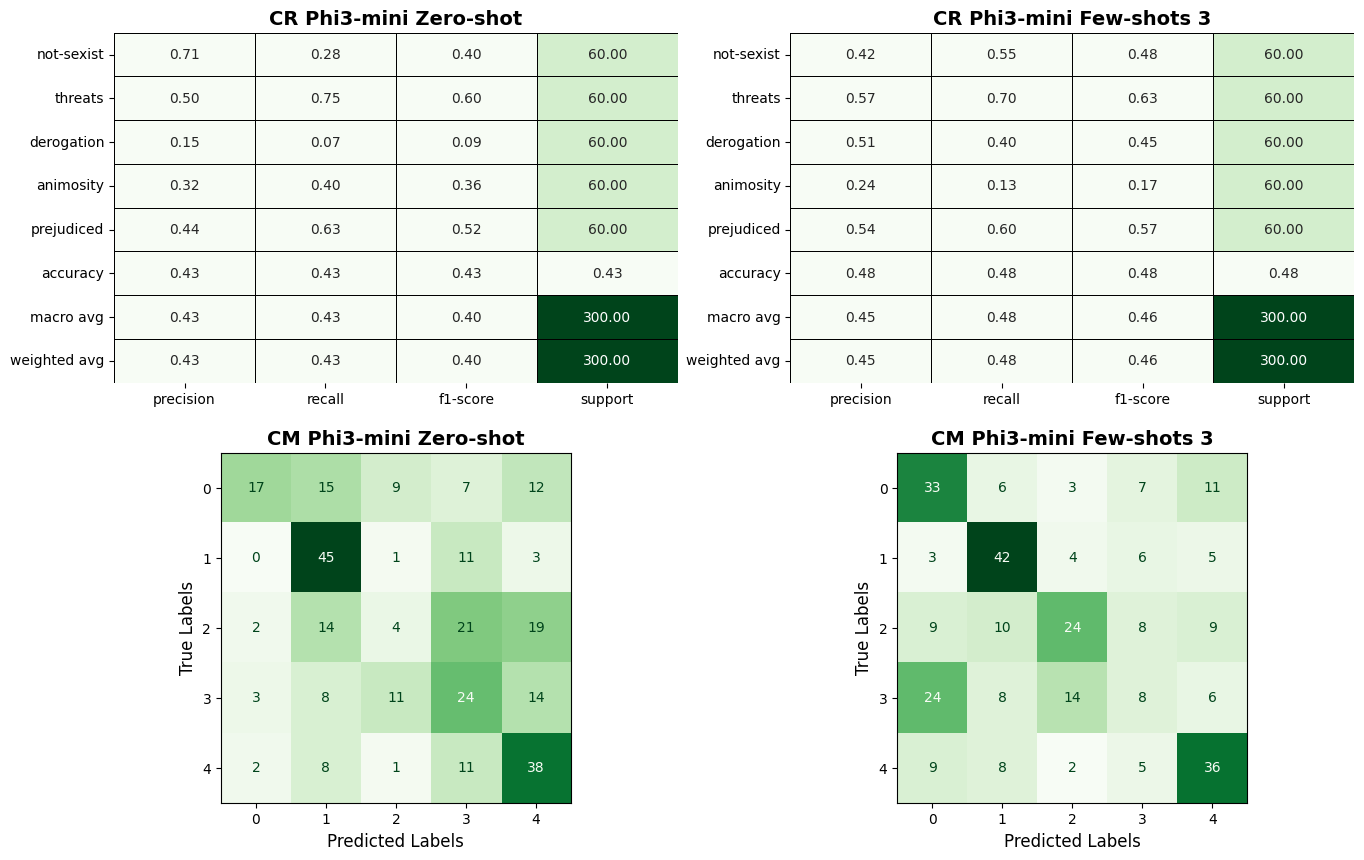

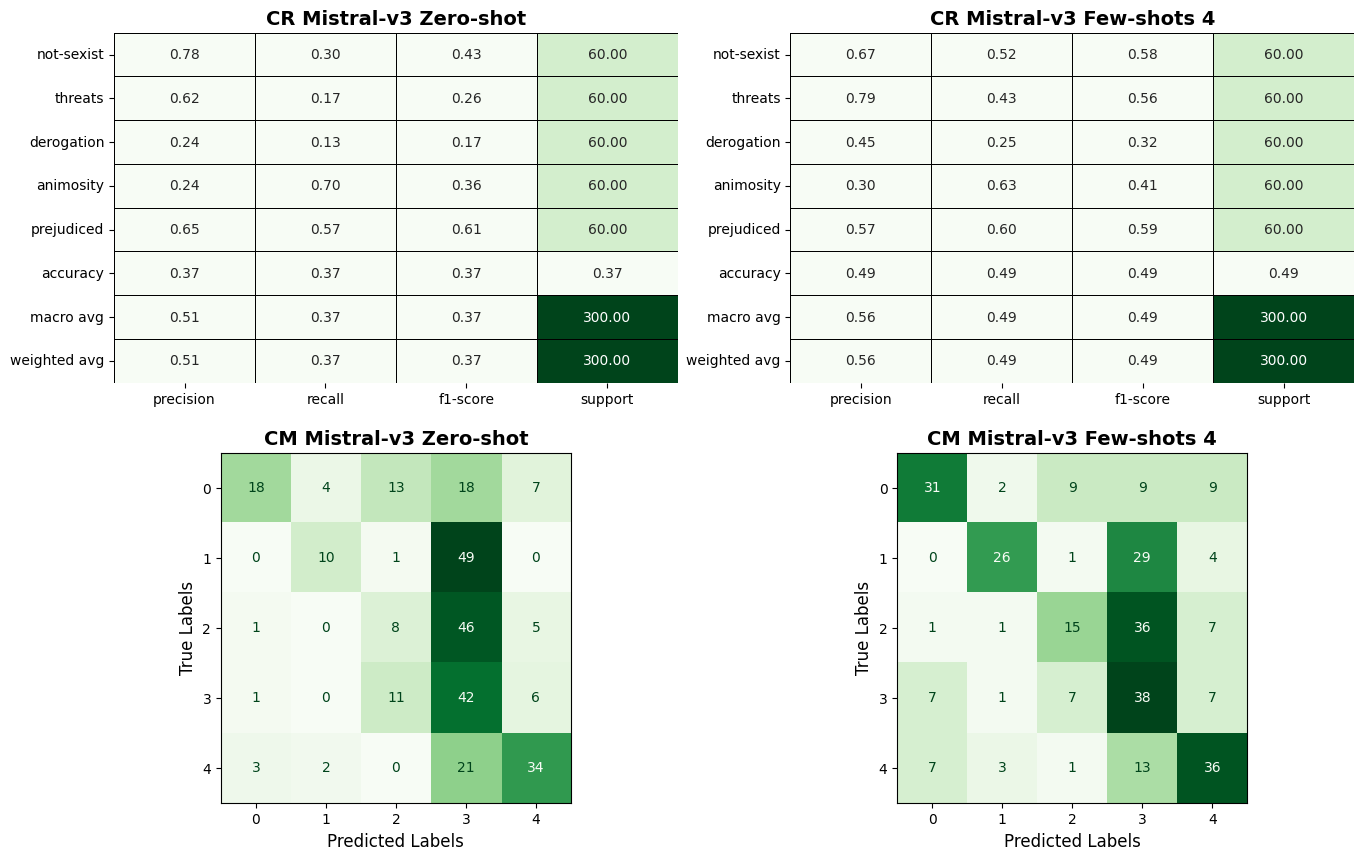

In [32]:
true_labels = [cfg["mapping"].get(lbl) for lbl in df['label_category']]
few_shot_indexes=[3,4] # phi3-mini, Mistral

for i,(model_name,model_info) in enumerate(models.items()):

    fig,axes = plt.subplots(2,2,figsize=(16,10))

    preds_zero_shot = model_info['metrics_dict_zero_shot']['pred_labels']
    preds_few_shots=[]
    preds_few_shots = model_info[f'metrics_dict_few_shots_{few_shot_indexes[i]}']['pred_labels']


    plot_classification_report(
        preds_zero_shot,
        true_labels,
        f"{model_name} Zero-shot",
        mapping=cfg["mapping"],
        ax=axes[0,0]
    )

    plot_classification_report(
        preds_few_shots,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes[i]}",
        mapping=cfg["mapping"],
        ax=axes[0,1]
    )

    plot_confusion_matrix(
        preds_zero_shot,
        true_labels,
        f"{model_name} Zero-shot",
        ax=axes[1,0]
    )

    plot_confusion_matrix(
        preds_few_shots,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes[i]}",
        ax=axes[1,1]
    )
    plt.show()


As we can see from the classification reports, adding examples to the prompt generally improves the F1-score across all classes for both models. The only exception is the 'animosity' class in the Phi-3 Mini model, which shows a notable drop in performance compared to the zero-shot setting. A possible hypothesis is that the examples provided for that class were not the most semantically relevant as they were selected randomly.

We try to evidence some common sentences which both zero shot and few shots miss for both models. Since all models miss these sentences we can consider them hard to recongize.

In [ ]:
def get_errors(sentences, pred_labels, true_labels, error_indexes):
  """Function to get model errors and indexes
  
  :param sentences: list of input sentences
  :param pred_labels: list of predicted labels
  :param true_labels: list of ground-truth labels
  :param error_indexes: list of indexes where the model produced an error

  """
  results=[]
  for i in range(len(sentences)):
      if i not in error_indexes and pred_labels[i] != true_labels[i]:
        results.append({
            "index":i,
            "text":sentences[i],
            "pred_label":pred_labels[i],
            "true_label":true_labels[i]
            })
  return results

In [ ]:
errors_phi3_zero_shot=get_errors(df['text'],models['Phi3-mini']['metrics_dict_zero_shot']['pred_labels'],true_labels,models['Phi3-mini']['metrics_dict_zero_shot']['errors_indexes'])
errors_mistralV3_zero_shot=get_errors(df['text'],models['Mistral-v3']['metrics_dict_zero_shot']['pred_labels'],true_labels,models['Mistral-v3']['metrics_dict_zero_shot']['errors_indexes'])
errors_phi3_few_shot=get_errors(df['text'],models['Phi3-mini']['metrics_dict_few_shots_3']['pred_labels'],true_labels,models['Phi3-mini']['metrics_dict_few_shots_3']['errors_indexes'])
errors_mistralV3_few_shot=get_errors(df['text'],models['Mistral-v3']['metrics_dict_few_shots_4']['pred_labels'],true_labels,models['Mistral-v3']['metrics_dict_few_shots_4']['errors_indexes'])

all_wrong_indices=[
    [error['index'] for error in errors_phi3_zero_shot],
    [error['index'] for error in errors_mistralV3_zero_shot],
    [error['index'] for error in errors_phi3_few_shot],
    [error['index'] for error in errors_mistralV3_few_shot]]

common_wrong_indices = set(all_wrong_indices[0]) & set(all_wrong_indices[1]) & set(all_wrong_indices[2]) & set(all_wrong_indices[3])
inverse_mapping = {v: key for key,v in cfg["mapping"].items()}

errors_to_print=[]
for idx in list(common_wrong_indices)[:10]:
    errors_to_print.append({
        'True': df['label_category'][idx],
        'Phi3_Zero':inverse_mapping[models['Phi3-mini']['metrics_dict_zero_shot']['pred_labels'][idx]],
        'Mistral_Zero':inverse_mapping[models['Mistral-v3']['metrics_dict_zero_shot']['pred_labels'][idx]],
        'Phi3_Few': inverse_mapping[models['Phi3-mini']['metrics_dict_few_shots_3']['pred_labels'][idx]],
        'Mistral_Few':inverse_mapping[models['Mistral-v3']['metrics_dict_few_shots_4']['pred_labels'][idx]],
        'Text': df['text'][idx]
    })

common_errors_df = pd.DataFrame(errors_to_print)
pd.set_option("display.max_colwidth", None)
common_errors_df


,True,Phi3_Zero,Mistral_Zero,Phi3_Few,Mistral_Few,Text
0,prejudiced,derogation,animosity,derogation,animosity,"Sell it to who pays more man. chicks come and go cash is forever. plus it'll tell her you arent a simp who will do anything for the pussy. side note, i dont know how you put up with chicks that talk in slang or like a dude, bugs the shit out of me"
1,derogation,threats,animosity,threats,animosity,Maybe the Mayoress or whatever pronoun the cunt answers to should stop sheltering illegal migrant criminals?
2,derogation,animosity,animosity,animosity,animosity,"""That tall man must certaily be better with women because of his large muscles, big penis ... just imagine him naked, those perfect lines, naked muscles .... that is why I hate women"""
3,prejudiced,threats,animosity,not-sexist,not-sexist,"If she said, ""tonight im getting wasted and riding that dick"" her consent was preregistered with thw caveat of she knew she would be drunk. You could not force her but if she is well receiving in her drunkenness i consider that continued consent."
4,derogation,prejudiced,animosity,prejudiced,animosity,"Better yet, completely ignore women whenever possible. And certainly always be cagey. [Treat them like you would treat a police officer]([URL] The one mistake the OP's boss made was divulging personal details to a woman."
5,derogation,animosity,animosity,threats,animosity,"Jehmu Greene is obviously lying because the first person she knows is herself. And no one would rape that, that alone fuck it willingly."
6,prejudiced,animosity,animosity,threats,animosity,"It was rape because she regretted it afterwards, duh. There's no way she could have sex with a nerd. Sheesh."
7,prejudiced,animosity,animosity,threats,animosity,don't get pissy with me because you're an asshole that thinks women are terrified pussies who should be allowed to accuse men 20 years later without proof.
8,threats,prejudiced,animosity,prejudiced,prejudiced,"[URL] Muslims home roots no need for women , closed their holes . Genital mutilation , Infections & death is what a women deserve they rather fuck boys & goats. Sex with women is anal anyway . Muslims culture is beautiful homos that act like real men"
9,not-sexist,animosity,animosity,animosity,animosity,"Do yourself a favor. Dont dignify a thing,by callin it a she.👍Thats a fuckin abomimation."


As shown from the table above, common errors are made on sentences that are difficult to categorize also for humans. Furthermore, some sentences may contain multiple labels or be written with sarcasm, which is particularly challenging to detect.

Models error correction moving from zero shot to few shot.

In [ ]:
def get_model_corrections(model_name,true_labels,errors_zero_shot,errors_few_shot,models,inverse_mapping,df,limit=10,few_shot_index=3):
    """
    Function to get the corrected classifications moving from zero shot to few shot.
    """
    zero_preds= models[model_name]['metrics_dict_zero_shot']['pred_labels']
    few_preds= models[model_name][f'metrics_dict_few_shots_{few_shot_index}']['pred_labels']

    zero_wrong=[]
    few_correct=[]

    for i in range(len(true_labels)):
      if i not in errors_zero_shot and zero_preds[i]!=true_labels[i]:
        zero_wrong.append(i)

    for i in range(len(true_labels)):
      if i not in errors_few_shot and few_preds[i]==true_labels[i]:
        few_correct.append(i)

    corrected_indices = set(zero_wrong) & set(few_correct)

    corrections_data = []
    for idx in list(corrected_indices)[:limit]:
        corrections_data.append({
            'Model': model_name,
            'True_Label': inverse_mapping[true_labels[idx]],
            'Zero_Shot_Wrong': inverse_mapping[zero_preds[idx]],
            'Few_Shot_Correct': inverse_mapping[few_preds[idx]],
            'Text': df['text'].iloc[idx]
        })

    return pd.DataFrame(corrections_data)

In [ ]:
phi3_corrections_df = get_model_corrections(
    model_name='Phi3-mini',
    true_labels=true_labels,
    errors_zero_shot=errors_phi3_zero_shot,
    errors_few_shot=errors_phi3_few_shot,
    models=models,
    inverse_mapping=inverse_mapping,
    df=df,
    limit=5,
    few_shot_index=3
)
phi3_corrections_df

,Model,True_Label,Zero_Shot_Wrong,Few_Shot_Correct,Text
0,Phi3-mini,derogation,animosity,derogation,Two thoughts to keep in mind about women and AA. 1) Show me a hot girl and I'll show you a man sick of all her bullshit. 2) She has messy diarrhea and loud farts just like the rest of us.
1,Phi3-mini,not-sexist,derogation,not-sexist,"NTA you were just being a free and independent girl, everyone makes mistakes at those ages, if he can’t accept that it was just a little mistake all those years ago he’s seriously as pathetic as your brother"
2,Phi3-mini,not-sexist,derogation,not-sexist,Her social skills are lacking as does yours. Did you miss her too? I sense you were hurt by her absence.
3,Phi3-mini,prejudiced,animosity,prejudiced,"Just so you know that my assertion notated above is spot on check out this article on this ""Olympian"" who feels so ashamed of the sexual assault that she received that she is not posing in her underwear. Her hypocrisy knows no bounds. [URL]"
4,Phi3-mini,threats,animosity,threats,You be on your knees suckin dick till your weak shins bruisin While yo girl take my >>FOOT<<long to her face like it was Sweet Chin Music


In [ ]:
mistralV3_corrections_df = get_model_corrections(
    model_name='Mistral-v3',
    true_labels=true_labels,
    errors_zero_shot=errors_mistralV3_zero_shot,
    errors_few_shot=errors_mistralV3_few_shot,
    models=models,
    inverse_mapping=inverse_mapping,
    df=df,
    limit=5,
    few_shot_index=4
)
mistralV3_corrections_df

,Model,True_Label,Zero_Shot_Wrong,Few_Shot_Correct,Text
0,Mistral-v3,derogation,animosity,derogation,She may be worth what someone paid for her in terms of stimulating walking away.
1,Mistral-v3,derogation,animosity,derogation,Two thoughts to keep in mind about women and AA. 1) Show me a hot girl and I'll show you a man sick of all her bullshit. 2) She has messy diarrhea and loud farts just like the rest of us.
2,Mistral-v3,not-sexist,derogation,not-sexist,"NTA you were just being a free and independent girl, everyone makes mistakes at those ages, if he can’t accept that it was just a little mistake all those years ago he’s seriously as pathetic as your brother"
3,Mistral-v3,not-sexist,derogation,not-sexist,Her social skills are lacking as does yours. Did you miss her too? I sense you were hurt by her absence.
4,Mistral-v3,threats,animosity,threats,"Hi Amelia, your site is fucking garbage. Please kill yourself."


Now we analyze models answers errors.

In [ ]:
def extract_answer_from_error_response(response):
    """
    Function to extract the answer error.

    :param response: the response (which contains also the question)
    :return: the cleaned answer
    """
    try:
        answer_match = [m for m in re.finditer('ANSWER:', response)]
        if answer_match:
            answer_start_point = answer_match[-1].end()
            full_answer = response[answer_start_point:].strip()
            return full_answer
        else:
            return response.strip()
    except:
        return response

In [ ]:
for model_name,model_info in models.items():
    zero_shot_errors=model_info['metrics_dict_zero_shot']['errors_answer']
    index = 0 if model_name == 'Phi3-mini' else 1
    few_shot_errors2 = model_info[f'metrics_dict_few_shots_2']['errors_answer']
    few_shot_errors3 = model_info[f'metrics_dict_few_shots_3']['errors_answer']
    few_shot_errors4 = model_info[f'metrics_dict_few_shots_4']['errors_answer']
    print("#"*80)
    print(f"Model: {model_name}")
    print("#"*80)
    print(f"\nZero-shot error answers ({len(zero_shot_errors)} total):")
    print("-"*50)
    for i, error_response in enumerate(zero_shot_errors):
        full_answer = extract_answer_from_error_response(error_response)
        print(f"{i+1}. Full answer: '{full_answer}'")
        print()

    print(f"\nFew-shot 2 error answers ({len(few_shot_errors2)} total):")
    print("-" * 50)
    for i, error_response in enumerate(few_shot_errors2):
        full_answer = extract_answer_from_error_response(error_response)
        print(f"{i+1}. Full answer: '{full_answer}'")
        print()

    print(f"\nFew-shot 3 error answers ({len(few_shot_errors3)} total):")
    print("-" * 50)
    for i, error_response in enumerate(few_shot_errors3):
        full_answer = extract_answer_from_error_response(error_response)
        print(f"{i+1}. Full answer: '{full_answer}'")
        print()

    print(f"\nFew-shot 4 error answers ({len(few_shot_errors4)} total):")
    print("-" * 50)
    for i, error_response in enumerate(few_shot_errors4):
        full_answer = extract_answer_from_error_response(error_response)
        print(f"{i+1}. Full answer: '{full_answer}'")
        print()

################################################################################
Model: Phi3-mini
################################################################################

Zero-shot error answers (0 total):
--------------------------------------------------

Few-shot 2 error answers (0 total):
--------------------------------------------------

Few-shot 3 error answers (0 total):
--------------------------------------------------

Few-shot 4 error answers (0 total):
--------------------------------------------------
################################################################################
Model: Mistral-v3
################################################################################

Zero-shot error answers (1 total):
--------------------------------------------------
1. Full answer: 'animosity, derogation, prejudiced'


Few-shot 2 error answers (2 total):
--------------------------------------------------
1. Full answer: 'animosity, prejudiced'

2. Full answer: 'anim

As we can see, errors are derived from multiple categories outputted from Mistral, possibly due to the previously mentioned issue that some sentences can be assigned to multiple labels.

Word error analysis

In [ ]:
def wrong_words_plotting(true_labels: np.ndarray, predictions: np.ndarray,sentences: List[str],model_name:str,mapping:dict, k_words=10):
    """
    Function used to plot the most misclassified examples in the test set for the specific model.

    :param true_labels: the true labels
    :param predictions: the predicted labels
    :param test_dataset: the test dataset on which to test the model
    :param model_name: the name of the model
    :param k_words: number of top words to display
    """
    sentences_tokens = [sentence.split() for sentence in sentences]
    ignore_words=set(stopwords.words('english')) | {'<pad>','<unk>','like'}
    df=pd.DataFrame({
        "sentences":sentences_tokens,
        "true_label":true_labels,
        "pred_label":predictions.astype(int)
    })

    n_labels=len(np.unique(true_labels))
    columns=min(2,n_labels)
    rows=math.ceil(n_labels/columns)

    fig,axs=plt.subplots(rows,columns,figsize=(6*columns,4*rows))
    fig.suptitle(f'{model_name} -- Most frequent words misclassified for each class')

    if rows == 1 and columns == 1:
        axs = [axs]
    else:
        axs = axs.flatten()

    for label in range(n_labels):

        ax = axs[label]
        subset = df[df['true_label']==label]

        # counting all words
        all_words = Counter(word.lower() for row in subset["sentences"]
            for word in row if word.lower() not in ignore_words)

        # counting the words in the misclassified samples
        df_wrong = subset[subset['true_label']!=subset['pred_label']]
        wrongest_words = Counter(word.lower() for row in df_wrong["sentences"]
            for word in row if word.lower() not in ignore_words)

        # we show the top k-wrongest words per class
        top_k_wrongest_word = wrongest_words.most_common(k_words)[::-1]
        wr_words,wr_counts = zip(*top_k_wrongest_word) if top_k_wrongest_word else ([],[])

        # get the words for the sentences
        total_count = [all_words[word] for word in wr_words]

        y_pos = range(len(wr_words))

        # barchart creation
        ax.barh(y_pos,total_count,color="lightblue",alpha=0.6,label='All Sentences')
        ax.barh(y_pos,wr_counts,color="red",alpha=0.8,label='Misclassified')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(wr_words)
        ax.set_xlabel('Word frequency')
        ax.set_title(f"Misclassified words for label '{list(mapping.keys())[label]}'")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend()
        ax.grid(axis='x')

    for i in range(n_labels, len(axs)):
        axs[i].set_visible(False)

    plt.tight_layout()
    plt.show()

In [ ]:
true_labels = [cfg["mapping"].get(lbl) for lbl in df['label_category']]
sentences = df['text'].tolist()

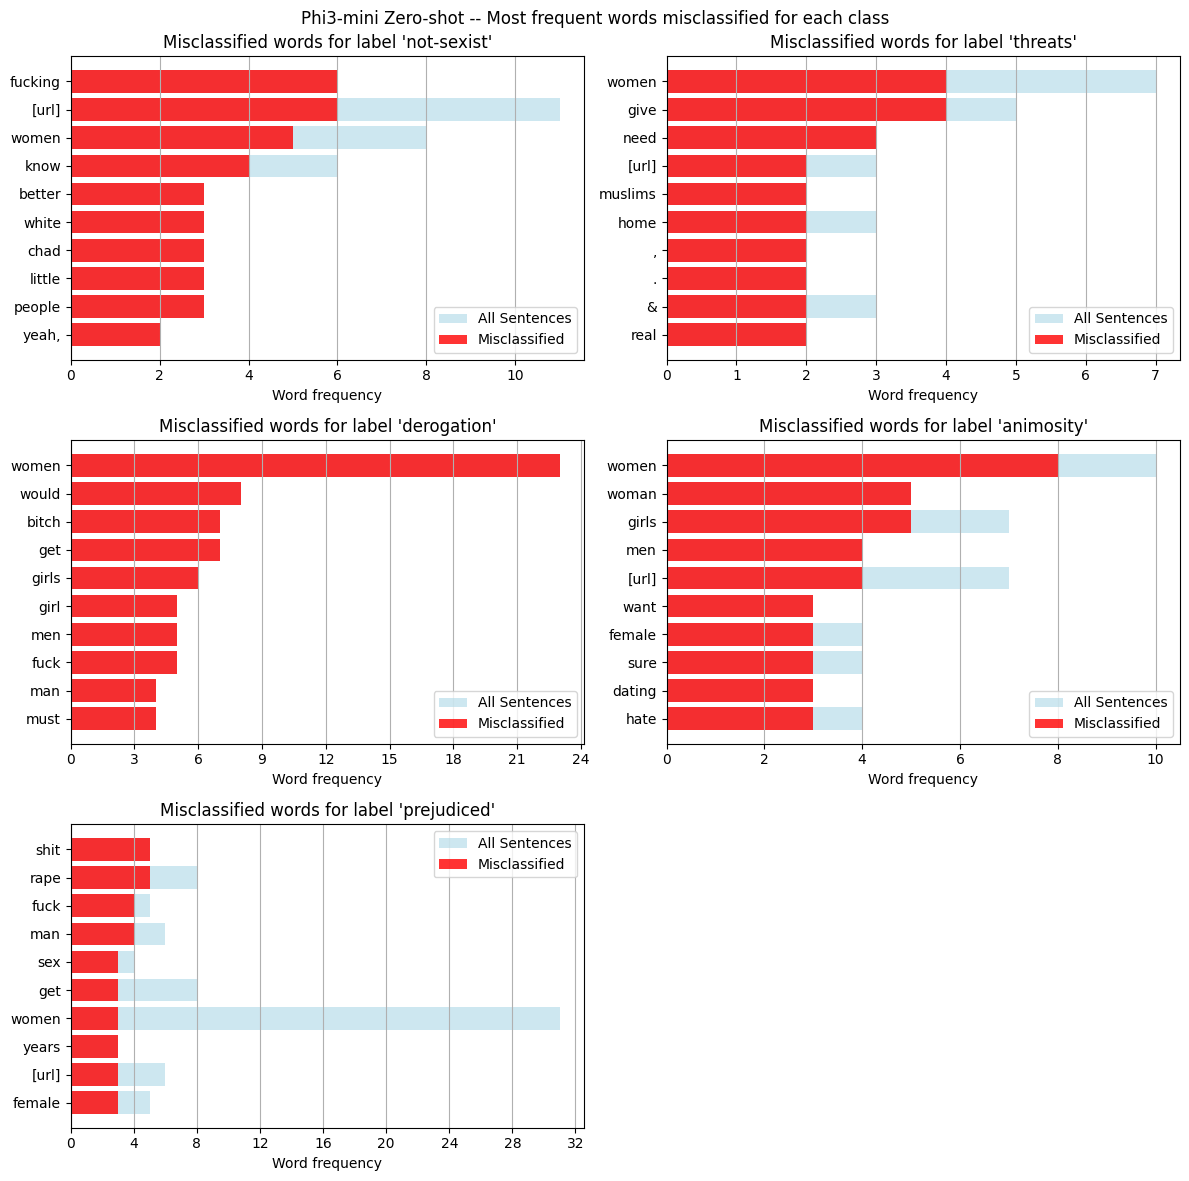

In [ ]:
phi3_zero_preds = models['Phi3-mini']['metrics_dict_zero_shot']['pred_labels']
wrong_words_plotting(
    true_labels=np.array(true_labels),
    predictions=np.array(phi3_zero_preds),
    sentences=sentences,
    model_name="Phi3-mini Zero-shot",
    mapping=cfg["mapping"]
)

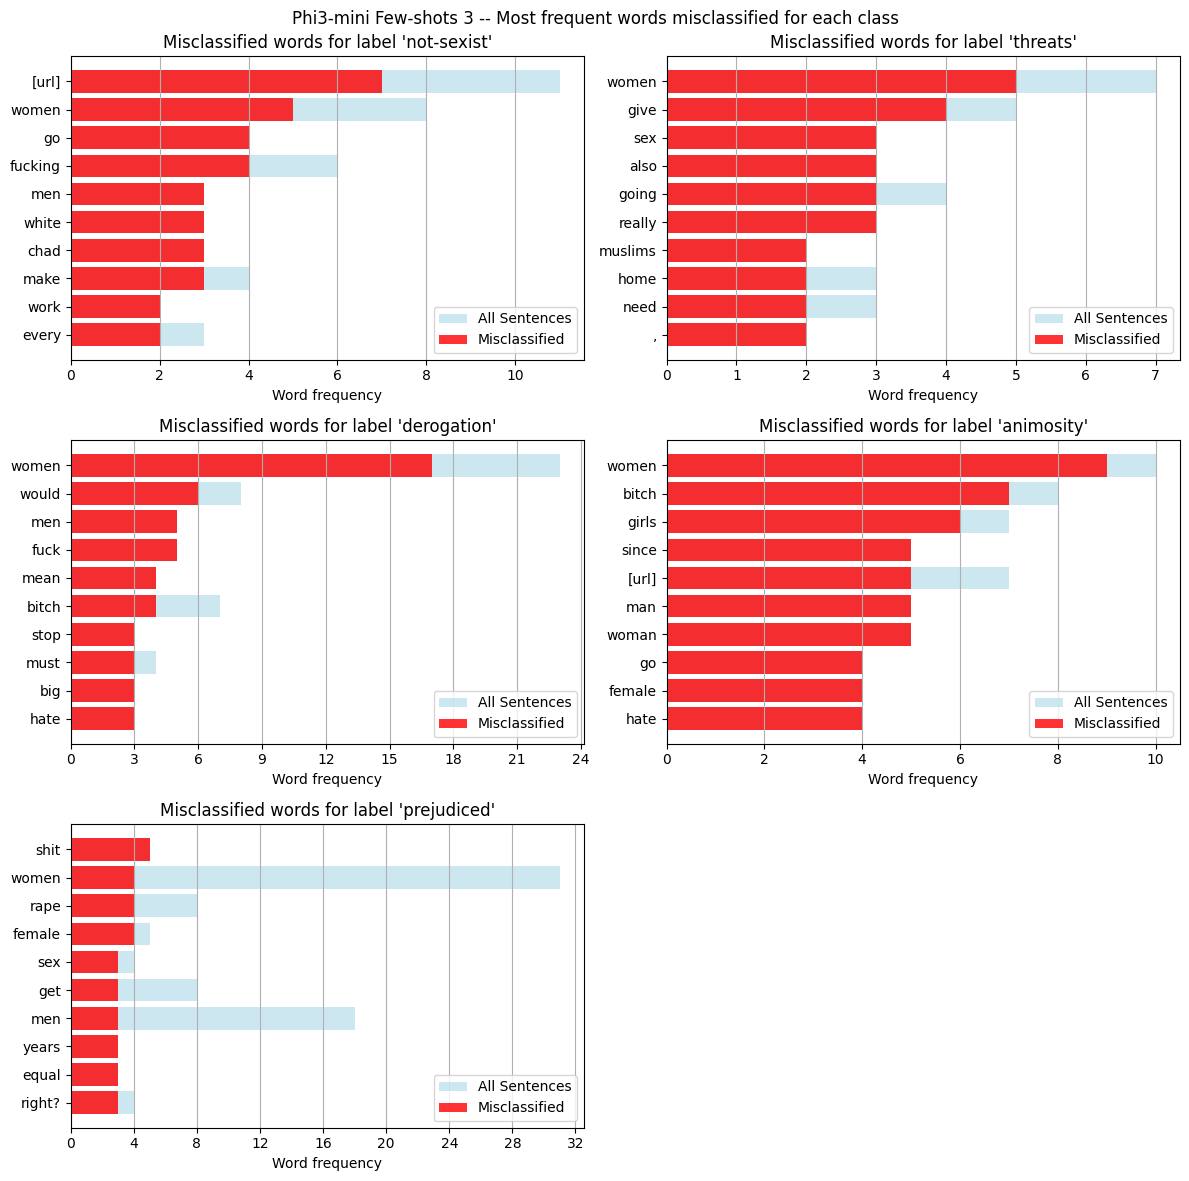

In [ ]:
phi3_few_preds = models['Phi3-mini']['metrics_dict_few_shots_3']['pred_labels']
wrong_words_plotting(
    true_labels=np.array(true_labels),
    predictions=np.array(phi3_few_preds),
    sentences=sentences,
    model_name="Phi3-mini Few-shots 3",
    mapping=cfg["mapping"]
)

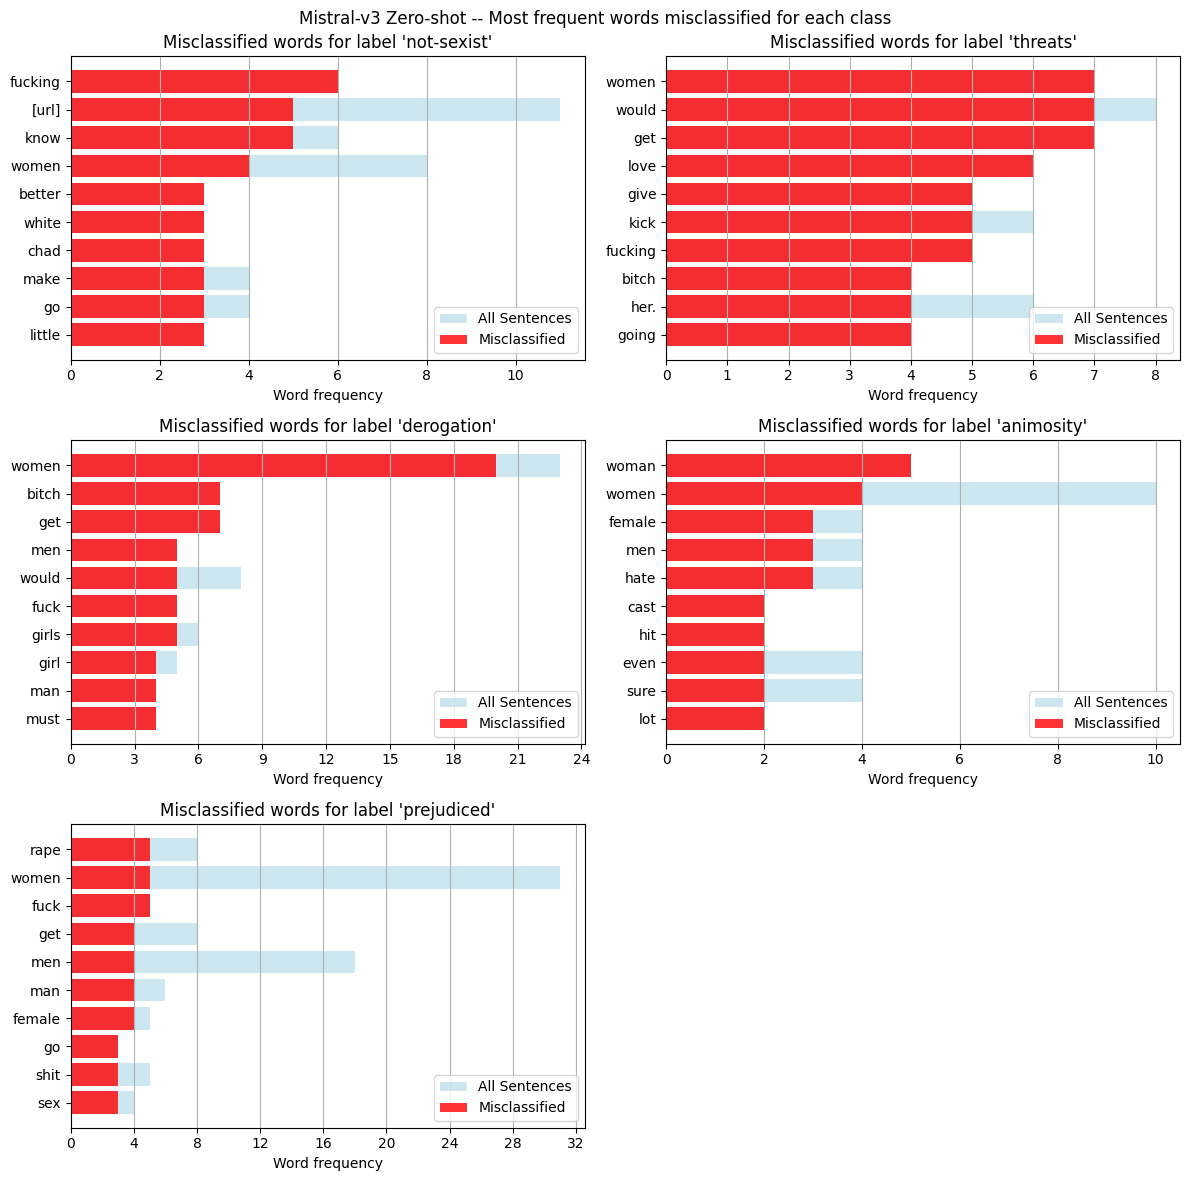

In [ ]:
mistral_zero_preds = models['Mistral-v3']['metrics_dict_zero_shot']['pred_labels']
wrong_words_plotting(
    true_labels=np.array(true_labels),
    predictions=np.array(mistral_zero_preds),
    sentences=sentences,
    model_name="Mistral-v3 Zero-shot",
    mapping=cfg["mapping"]
)

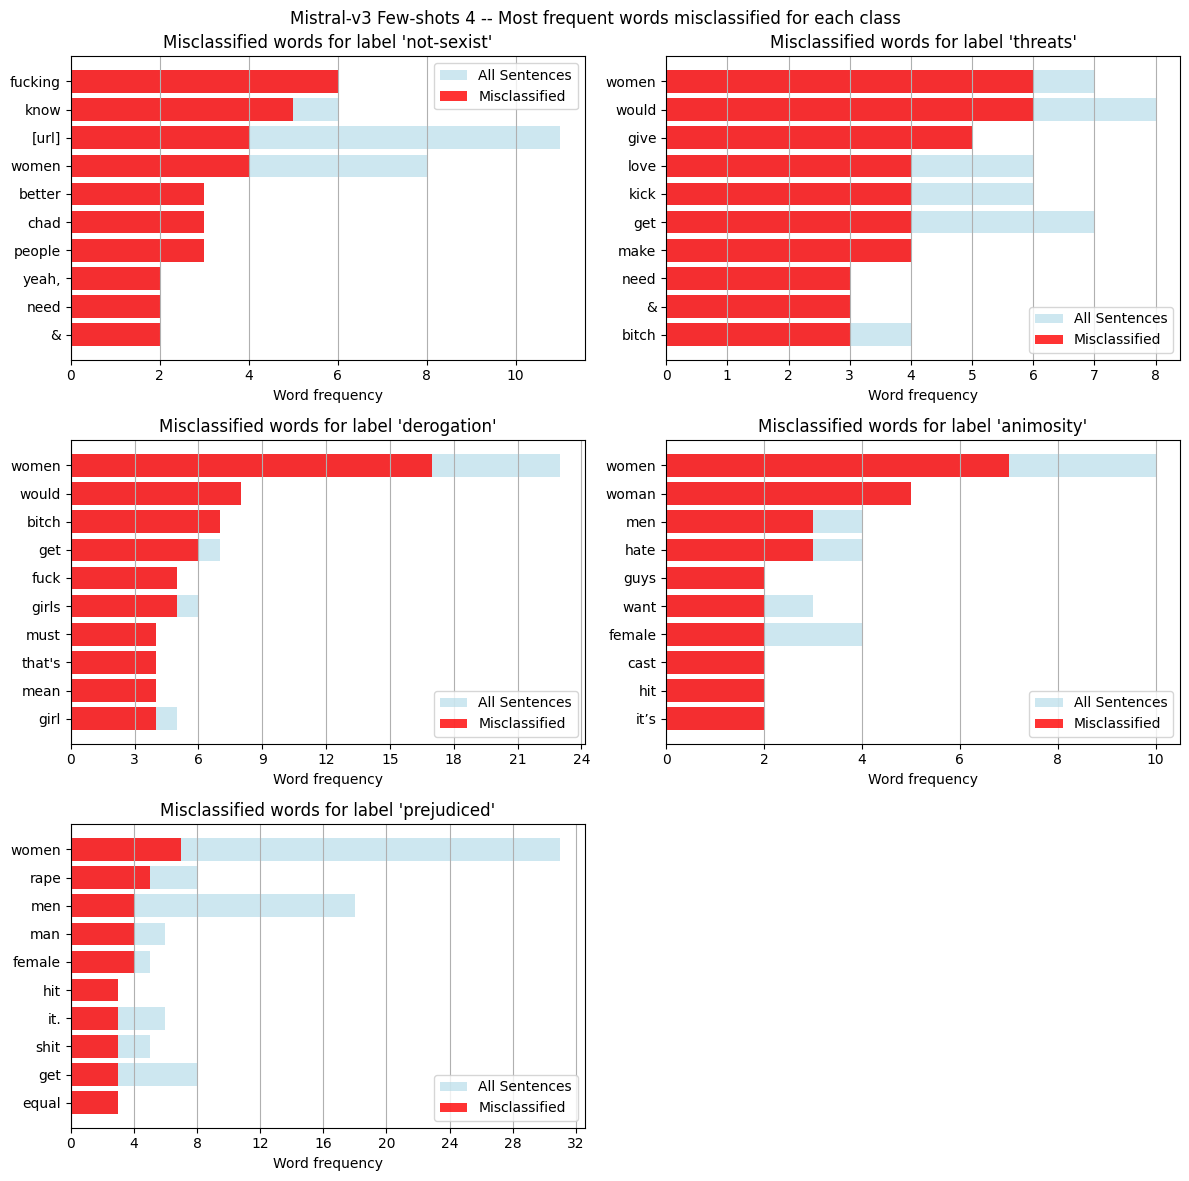

In [ ]:
mistral_few_preds = models['Mistral-v3']['metrics_dict_few_shots_4']['pred_labels']
wrong_words_plotting(
    true_labels=np.array(true_labels),
    predictions=np.array(mistral_few_preds),
    sentences=sentences,
    model_name="Mistral-v3 Few-shots 4",
    mapping=cfg["mapping"]
)

As expected, the word "women" is among the most frequent across all classes, but we do not observe any significant patterns linking specific words to misclassifications.

# Bonus Points

We decided to investigate whether few-shot inference performance could be improved by selecting examples in a structured manner rather than at random. Specifically, for each category, we compute the embeddings for all available examples and derived a centroid representation. We then evaluated two different selection strategies:

1.   Selecting the examples closest to the centroid. (We will refer to that with the name `only_similar`)
2.   Selecting a combination of the nearest and the farthest examples relative to the centroid. (We will refer to that with the name `also_similar`)

For the second strategy, the selection depends on the number of examples
𝑁 used per category:

*   𝑁 = 2: 1 nearest and 1 fartherst example.
*   𝑁 = 3: 2 nearest and 1 fartherst example.
*   𝑁 = 4: 2 nearest and 2 fartherst examples.



In [19]:
def get_demonstrations(rows: pd.DataFrame, num_per_class: int, model: SentenceTransformer, only_similar: bool) -> list:
  """
  Selects a set of demonstration examples from a single category based on
  similarity to the category centroid in embedding space.

  :param rows: the rows of the dataset containing the examples of a single category.
  :param num_per_class: the number of examples to select.
  :param model: the model to compute embeddings of demonstrations.
  :param only_similar: whether to only select examples that are similar to the category centroid.

  :returns:
    - the list of demonstrations for a single category to inject into the prompt template.
  """
  demonstrations = []

  if only_similar:
    n_sim = num_per_class
  else:
    n_sim, n_diff = 1, 1
    if(num_per_class == 3):
      n_sim = 2
    if(num_per_class == 4):
      n_diff = 2

  texts = rows["text"]

  # Compute embeddings and centroid
  embeddings = model.encode(texts, convert_to_tensor=True)
  centroid = embeddings.mean(dim=0, keepdim=True)

  # Similarity to centroid
  sims = util.cos_sim(embeddings, centroid).squeeze()

  # n_sim most similar
  sim_idx = torch.topk(sims, k=n_sim, largest=True).indices.tolist()
  for i in sim_idx:
    demonstrations.append((rows.iloc[i]['text'], rows.iloc[i]['label_category']))

  # n_diff least similar
  if not only_similar:
    diff_idx = torch.topk(sims, k=n_diff, largest=False).indices.tolist()
    for i in diff_idx:
      demonstrations.append((rows.iloc[i]['text'], rows.iloc[i]['label_category']))

  return demonstrations

def build_few_shot_demonstrations(demonstrations: pd.DataFrame, num_per_class: int, model: SentenceTransformer, only_similar: bool) -> list:
  """
  :param demonstrations: DataFrame wrapping demonstrations examples
  :param num_per_class: the number of demonstrations per class
  :param model: the model to compute embeddings of demonstrations.

  :returns:
      - the list of demonstrations for all the categories to inject into the prompt template.
  """
  demonstrations_samples_categories=[]

  for category in demonstrations['label_category'].unique():
    category_texts = demonstrations[demonstrations['label_category']==category].reset_index(drop=True)
    demonstrations_samples_categories.extend(get_demonstrations(category_texts, num_per_class, model, only_similar))

  formatted_demonstrations = "\n".join(
      f"TEXT: {text}\nANSWER: {label}"
      for text, label in demonstrations_samples_categories
  )
  return formatted_demonstrations

In [20]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [21]:
few_shots_demonstrations_only_similar={}
few_shots_demonstrations_also_similar={}
for num_examples in cfg["num_per_classes"]:
  few_shots_demonstrations_only_similar[num_examples] = build_few_shot_demonstrations(demonstrations = df_few_shot,
                                                              num_per_class = num_examples,
                                                              model=model,
                                                              only_similar=True
                                                              )
  few_shots_demonstrations_also_similar[num_examples] = build_few_shot_demonstrations(demonstrations = df_few_shot,
                                                              num_per_class = num_examples,
                                                              model=model,
                                                              only_similar=False
                                                              )

In [22]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    model_info[f"prompts_few_shots_{num_examples}_only_similar"] = prepare_prompts_few_shot(texts = df["text"],
                                                                               prompt_template = prompt,
                                                                               tokenizer = model_info["tokenizer"],
                                                                               demonstrations = few_shots_demonstrations_only_similar[num_examples])
    model_info[f"prompts_few_shots_{num_examples}_also_similar"] = prepare_prompts_few_shot(texts = df["text"],
                                                                               prompt_template = prompt,
                                                                               tokenizer = model_info["tokenizer"],
                                                                               demonstrations = few_shots_demonstrations_also_similar[num_examples])

In [ ]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    responses_only_similar =  generate_responses(model = model_info['model'],
                                    prompts = model_info[f"prompts_few_shots_{num_examples}_only_similar"])
    responses_also_similar =  generate_responses(model = model_info['model'],
                                    prompts = model_info[f"prompts_few_shots_{num_examples}_also_similar"])

    decoded_responses_only_similar = decode_responses(responses = responses_only_similar,
                                                      model_name = model_name)

    decoded_responses_also_similar = decode_responses(responses = responses_also_similar,
                                                      model_name = model_name)

    model_info[f'responses_few_shots_{num_examples}_only_similar'] = responses_only_similar
    model_info[f'responses_few_shots_{num_examples}_also_similar'] = responses_also_similar

    model_info[f'decoded_responses_few_shots_{num_examples}_only_similar'] = decoded_responses_only_similar
    model_info[f'decoded_responses_few_shots_{num_examples}_also_similar'] = decoded_responses_also_similar

In [ ]:
for model_name, model_info in models.items():
  for num_examples in cfg["num_per_classes"]:
    metrics_dict_only_similar = compute_metrics(y_pred = model_info[f'decoded_responses_few_shots_{num_examples}_only_similar'],
                                                                          y_true = df['label_category'])
    metrics_dict_also_similar = compute_metrics(y_pred = model_info[f'decoded_responses_few_shots_{num_examples}_also_similar'],
                                                                          y_true = df['label_category'])

    model_info[f'metrics_dict_few_shots_{num_examples}_only_similar'] = metrics_dict_only_similar
    model_info[f'metrics_dict_few_shots_{num_examples}_also_similar'] = metrics_dict_also_similar

In [15]:
first_model_output_df = pd.DataFrame(columns=['model_name','prompt_technique','only_similar','macro_f1','fail_ratio'])
second_model_output_df = pd.DataFrame(columns=['model_name','prompt_technique','only_similar','macro_f1','fail_ratio'])

for num_examples in cfg["num_per_classes"]:
  few_shot_key = f'metrics_dict_few_shots_{num_examples}'
  first_model_output_df.loc[len(first_model_output_df)]=[MODEL_NAME1,
                                f'few_shots_{num_examples}',
                                True,
                                models[MODEL_NAME1][few_shot_key+'_only_similar']['macro_f1'],
                                models[MODEL_NAME1][few_shot_key+'_only_similar']['fail_ratio']]
  first_model_output_df.loc[len(first_model_output_df)]=[MODEL_NAME1,
                                f'few_shots_{num_examples}',
                                False,
                                models[MODEL_NAME1][few_shot_key+'_also_similar']['macro_f1'],
                                models[MODEL_NAME1][few_shot_key+'_also_similar']['fail_ratio']]
  second_model_output_df.loc[len(second_model_output_df)]=[MODEL_NAME2,
                                f'few_shots_{num_examples}',
                                True,
                                models[MODEL_NAME2][few_shot_key+'_only_similar']['macro_f1'],
                                models[MODEL_NAME2][few_shot_key+'_only_similar']['fail_ratio']]
  second_model_output_df.loc[len(second_model_output_df)]=[MODEL_NAME2,
                                f'few_shots_{num_examples}',
                                False,
                                models[MODEL_NAME2][few_shot_key+'_also_similar']['macro_f1'],
                                models[MODEL_NAME2][few_shot_key+'_also_similar']['fail_ratio']]
display(first_model_output_df)
display(second_model_output_df)

,model_name,prompt_technique,only_similar,macro_f1,fail_ratio
0,Phi3-mini,few_shots_2,True,0.459115,0
1,Phi3-mini,few_shots_2,False,0.398582,0
2,Phi3-mini,few_shots_3,True,0.430519,0
3,Phi3-mini,few_shots_3,False,0.412295,0
4,Phi3-mini,few_shots_4,True,0.451588,0
5,Phi3-mini,few_shots_4,False,0.398699,0


,model_name,prompt_technique,only_similar,macro_f1,fail_ratio
0,Mistral-v3,few_shots_2,True,0.505955,0.010000
1,Mistral-v3,few_shots_2,False,0.480873,0.013333
2,Mistral-v3,few_shots_3,True,0.490336,0.010000
3,Mistral-v3,few_shots_3,False,0.502897,0.016667
4,Mistral-v3,few_shots_4,True,0.499523,0.003333
5,Mistral-v3,few_shots_4,False,0.482650,0.020000


From the obtained results, we observe that selecting only the nearest demonstrations for each category is more effective than combining nearest and farthest examples. This strategy leads to an improvement in performance for both models, whereas including the farthest demonstrations does not always provide additional benefits.

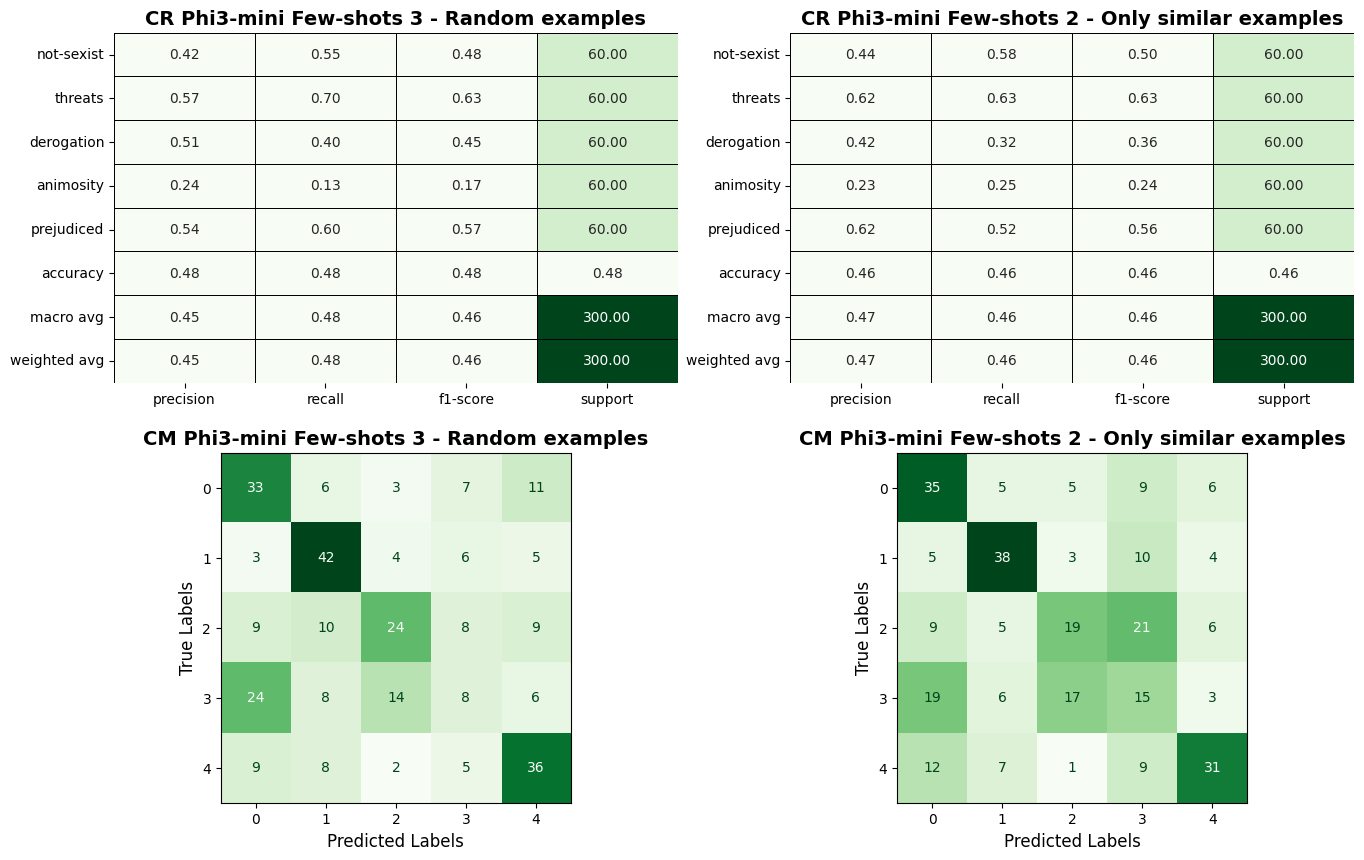

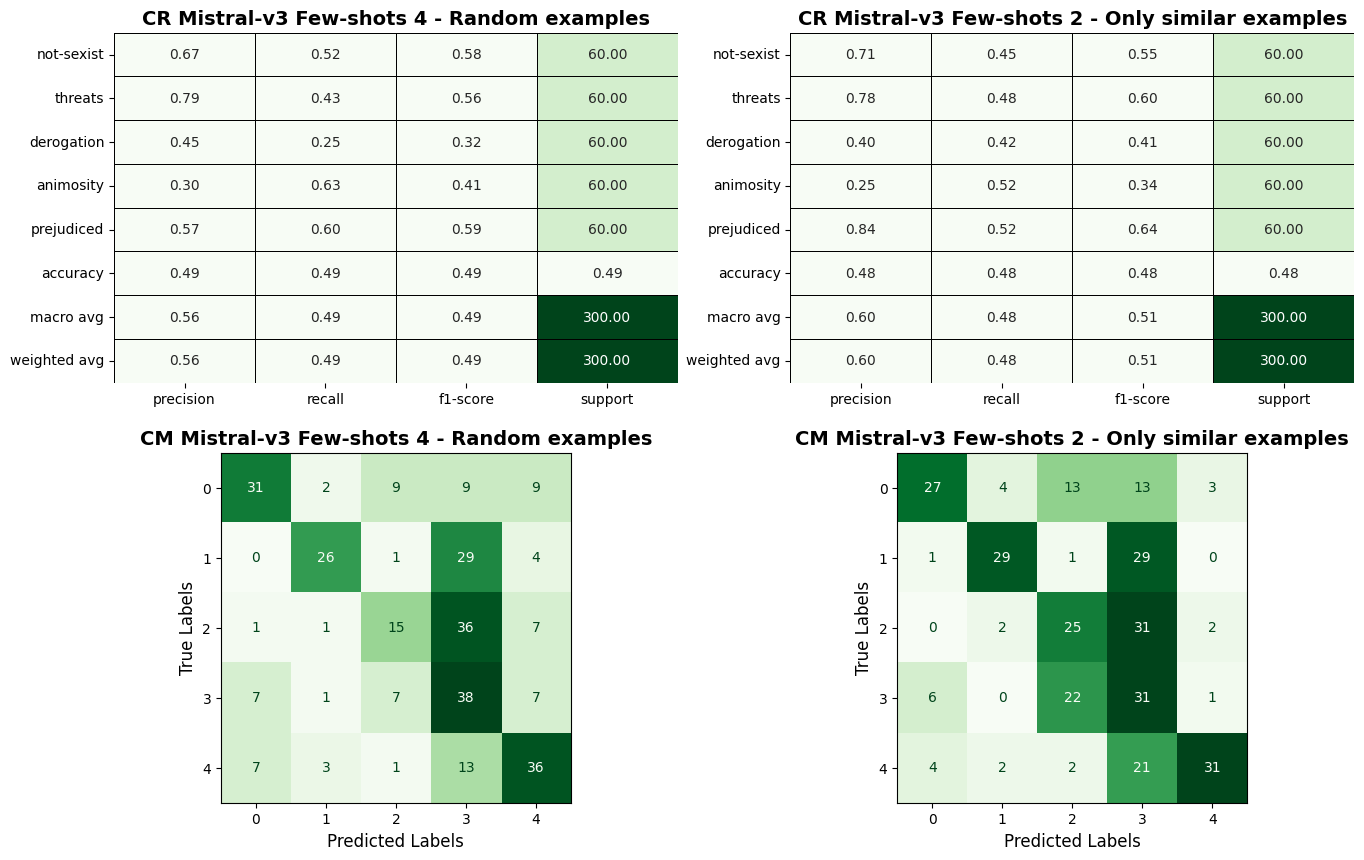

In [40]:
true_labels = [cfg["mapping"].get(lbl) for lbl in df['label_category']]
few_shot_indexes_only_similar=[2,2] # phi3-mini, Mistral --- best with only similar examples
few_shot_indexes = [3,4] # phi3-mini, Mistral --- best with random examples

for i,(model_name,model_info) in enumerate(models.items()):

    fig,axes = plt.subplots(2,2,figsize=(16,10))

    preds_zero_shot = model_info[f'metrics_dict_few_shots_{few_shot_indexes[i]}']['pred_labels']
    preds_few_shots=[]
    preds_few_shots = model_info[f'metrics_dict_few_shots_{few_shot_indexes_only_similar[i]}_only_similar']['pred_labels']


    plot_classification_report(
        preds_zero_shot,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes[i]} - Random examples",
        mapping=cfg["mapping"],
        ax=axes[0,0]
    )

    plot_classification_report(
        preds_few_shots,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes_only_similar[i]} - Only similar examples",
        mapping=cfg["mapping"],
        ax=axes[0,1]
    )

    plot_confusion_matrix(
        preds_zero_shot,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes[i]} - Random examples",
        ax=axes[1,0]
    )

    plot_confusion_matrix(
        preds_few_shots,
        true_labels,
        f"{model_name} Few-shots {few_shot_indexes_only_similar[i]} - Only similar examples",
        ax=axes[1,1]
    )
    plt.show()


As we can see, avoiding the random selection of examples for the prompt leads to slight improvements in almost all cases. In particular, in the 'Few-shots 3 – Random examples' setting, there was a significant drop in the F1-score for the "animosity" class compared to the zero-shot configuration. This drop was mitigated when examples were carefully selected, confirming that the performance decrease was due to the choice of examples.